In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=KAqky65jKNvo1IS3DnbvL7NqItCDKj&access_type=offline&code_challenge=Pv2_TSVRYJO4lP5-Ou80QB48i3p6wLrDZhonEKm_nKM&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


Updates are available for some Google Clo

In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/23 14:49:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"


si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

sl_eff=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect")

l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet")

# Data fro drug target enrichemnt

In [3]:
disease_index_path=path_to_release_folder+"output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path=path_to_release_folder+"output/evidence/sourceId=chembl"
chembl_evidence=session.spark.read.parquet(platform_chembl_evidence_path)

In [4]:
columns_to_select=["targetId","diseaseId"]

# L2G evidence

In [5]:
qd_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets").select("studyLocusId").cache()
qd_cs.count()

70618

In [6]:
l2g_full_diseases=l2g_full.join(qd_cs,"studyLocusId","inner").cache()
l2g_full_diseases.count()

70400

In [7]:
l2g_evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_diseases,
    score_column="score",
    datasource_id="l2g_combined",
    study_locus=sl,
    study_index=si,
    min_score=0.1
)

In [8]:
l2g_evidence_diseases=l2g_evidence.select(columns_to_select).distinct().withColumn("resourceScore",f.lit(1.0)).withColumn("source",f.lit("all_diseases")).cache()
l2g_evidence_diseases.count()

36858

In [9]:
l2g_evidence_VEP=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_diseases.filter(f.col("VEP")==1),
    score_column="score",
    datasource_id="l2g_VEP",
    study_locus=sl,
    study_index=si,
    min_score=0.1
)

In [10]:
l2g_evidence_VEP=l2g_evidence_VEP.select(columns_to_select).distinct().withColumn("resourceScore",f.lit(1.0)).withColumn("source",f.lit("gwas_with_pav")).cache()
l2g_evidence_VEP.count()

5441

In [11]:
l2g_evidence_eQTL=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_diseases.filter(f.col("eQTL_coloc")==1),
    score_column="score",
    datasource_id="l2g_eQTL",
    study_locus=sl,
    study_index=si,
    min_score=0.1
)

In [12]:
l2g_evidence_eQTL = l2g_evidence_eQTL.select(columns_to_select).distinct().withColumn("resourceScore",f.lit(1.0)).withColumn("source",f.lit("gwas_eQTL")).cache()
l2g_evidence_eQTL = l2g_evidence_eQTL.join(l2g_evidence_VEP.select(columns_to_select),on=["targetId","diseaseId"],how="left_anti").cache()
l2g_evidence_eQTL.count()

12343

In [13]:
l2g_evidence_eQTL.columns

['targetId', 'diseaseId', 'resourceScore', 'source']

In [14]:
qm_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_measurement_credible_sets").select("studyLocusId").cache()
qm_cs.count()

450357

In [15]:
l2g_measurements_full = l2g_full.join(qm_cs, on="studyLocusId", how="inner").cache()
l2g_measurements_full.count()

453009

In [16]:
l2g_evidence_measurements=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_measurements_full,
    score_column="score",
    datasource_id="l2g_measurements",
    study_locus=sl,
    study_index=si,
    min_score=0.1
)

In [17]:
l2g_evidence_measurements=l2g_evidence_measurements.select(columns_to_select).distinct().withColumn("resourceScore",f.lit(1.0)).withColumn("source",f.lit("all_measurements")).cache()
l2g_evidence_measurements.count()

150360

In [18]:
l2g_evidence_measurements.select("targetId").distinct().count()

15160

In [19]:
l2g_evidence_diseases.select("targetId").distinct().count()

8285

# OMIM

In [20]:
evidence=session.spark.read.parquet(path_to_release_folder+"/output/evidence")

In [21]:
evidence = evidence.filter(f.col("score")>=0).filter(f.col("datasourceId").isin([ "uniprot_variants", "uniprot_literature"])).cache()

25/09/19 18:32:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [22]:
evidence.groupBy("datasourceId").count().show()

+------------------+-----+
|      datasourceId|count|
+------------------+-----+
|  uniprot_variants|33047|
|uniprot_literature| 6744|
+------------------+-----+



In [23]:
evidence_omim = evidence.filter(f.col("diseaseFromSourceId").substr(1, 4) == "OMIM").cache()
evidence_omim.count()

39791

In [24]:
evidence_omim=evidence_omim.select(columns_to_select).distinct().withColumn("resourceScore",f.lit(1.0)).withColumn("source",f.lit("omim")).cache()
evidence_omim.count()

6645

In [25]:
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence_omim,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,1.219015,2.191984e-01,0.900268,1.650617,6114,30912,49,302,61009
1,3+,2.286880,4.792445e-14,1.834842,2.850283,20450,16576,123,228,61009
2,4+,5.131773,1.406205e-42,4.139005,6.362663,32606,4420,207,144,61009


# Orphanet evidence

In [26]:
evidence=session.spark.read.parquet(path_to_release_folder+"/output/evidence")

In [27]:
#evidence = evidence.filter(f.col("score")>=0.95).filter(f.col("datasourceId").isin(["eva", "uniprot_variants", "gene2phenotype", "genomics_england", "clingen","orphanet"])).cache()
evidence = evidence.filter(f.col("score")>=0).filter(f.col("datasourceId").isin(["orphanet"])).cache()
evidence.count()


6301

In [28]:
evidence_orphanet=evidence.select(columns_to_select).distinct().withColumn("resourceScore",f.lit(1.0)).withColumn("source",f.lit("orphanet")).cache()
evidence_orphanet.count()

6288

In [29]:
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence_orphanet,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,1.194982,2.925021e-01,0.873670,1.634463,6117,30936,46,278,59325
1,3+,2.366640,5.859771e-14,1.879705,2.979714,20462,16591,111,213,59325
2,4+,4.676656,1.306846e-34,3.732320,5.859924,32615,4438,198,126,59325


In [30]:
evidence_orphanet.columns

['targetId', 'diseaseId', 'resourceScore', 'source']

# Genebased results

In [5]:
evidence=session.spark.read.parquet(path_to_release_folder+"/output/evidence")

In [32]:
#evidence.groupBy("datasourceId").count().show()

In [33]:
evidence_gene_burden = evidence.filter(f.col("datasourceId")=="gene_burden").cache()
evidence_gene_burden.show(1)

+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------------------+----------------+---------------+----------+--------+-------------------+-------------------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+--------------------+----------+------------+-----------+--------------+-------------+----+------------------------+-------------

In [34]:
evidence_gene_burden.groupBy("statisticalMethod").count().show(100,truncate=False)

+----------------------------------------+-----+
|statisticalMethod                       |count|
+----------------------------------------+-----+
|ptvraredmg                              |3012 |
|ADD-WGR-FIRTH_M3.001                    |906  |
|pLoF                                    |2061 |
|ADD-WGR-FIRTH_M1.001                    |753  |
|LOF + missense0.8 (MAF<0.1%)            |293  |
|ADD-WGR-FIRTH_M1.1                      |953  |
|UR                                      |1521 |
|ADD-WGR-FIRTH_M3.01                     |1087 |
|LOF + missense0.5 (MAF<0.001%)          |190  |
|pLoF|missense|LC                        |2601 |
|ADD-WGR-FIRTH_M1.0001                   |482  |
|raredmg                                 |1155 |
|LOF (MAF<0.1%)                          |282  |
|URmtr                                   |1425 |
|ADD-WGR-FIRTH_M3.0001                   |517  |
|ADD-WGR-FIRTH_M1.01                     |842  |
|Cauchy                                  |403  |
|ADD-WGR-FIRTH_M3.1 

In [35]:
evidence_gene_burden_reg = evidence_gene_burden.filter(f.array_contains(f.col("literature"), "34662886"))
evidence_gene_burden_reg.show(1)

+------------+---------------+-------------+-------------------+--------+--------------+-----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+---------------+----------------+---------------+----------+--------+-------------------+-------------------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+--------------------+---

In [36]:
evidence_gene_burden_reg.groupBy("statisticalMethod").count().show(100,truncate=False)

+--------------------------+-----+
|statisticalMethod         |count|
+--------------------------+-----+
|ADD-WGR-FIRTH_M3.001      |906  |
|ADD-WGR-FIRTH_M1.001      |753  |
|ADD-WGR-FIRTH_M1.1        |953  |
|ADD-WGR-FIRTH_M3.01       |1087 |
|ADD-WGR-FIRTH_M1.0001     |482  |
|ADD-WGR-FIRTH_M3.0001     |517  |
|ADD-WGR-FIRTH_M1.01       |842  |
|ADD-WGR-FIRTH_M3.1        |1470 |
|ADD-WGR-FIRTH_M3.singleton|192  |
|ADD-WGR-FIRTH_M1.singleton|182  |
+--------------------------+-----+



In [37]:
evidence.filter(f.col("datasourceId")=="gene_burden").groupBy("projectId").count().show(100,truncate=False)

+----------------------------+-----+
|projectId                   |count|
+----------------------------+-----+
|FinnGen                     |433  |
|AstraZeneca PheWAS Portal   |21296|
|NULL                        |196  |
|Genebass                    |7342 |
|SCHEMA consortium           |10   |
|REGENERON                   |7384 |
|Autism Sequencing Consortium|102  |
|CVDI Human Disease Portal   |1428 |
|OTAR022                     |21   |
|AMP-PD                      |9    |
|Epi25 collaborative         |2    |
+----------------------------+-----+



In [38]:
evidence_genebass=evidence_gene_burden.filter(f.col("projectId")=="Genebass").filter(~(f.col("statisticalMethod")=="synonymous"))

In [39]:
evidence_genebass.groupBy("statisticalMethod").count().show(100,truncate=False)

+-----------------+-----+
|statisticalMethod|count|
+-----------------+-----+
|pLoF             |2061 |
|pLoF|missense|LC |2601 |
|missense|LC      |2127 |
+-----------------+-----+



In [40]:
evidence_finngen=evidence_gene_burden.filter(f.col("projectId")=="FinnGen")

In [41]:
evidence_AstraZeneca=evidence_gene_burden.filter(f.col("projectId")=="AstraZeneca PheWAS Portal")
evidence_AstraZeneca.groupBy("statisticalMethod").count().show(100,truncate=False)

+-----------------+-----+
|statisticalMethod|count|
+-----------------+-----+
|ptvraredmg       |3012 |
|UR               |1521 |
|raredmg          |1155 |
|URmtr            |1425 |
|ptv              |3392 |
|rec              |271  |
|syn              |56   |
|raredmgmtr       |565  |
|ptv5pcnt         |4346 |
|flexdmg          |3398 |
|flexnonsynmtr    |2155 |
+-----------------+-----+



In [42]:
evidence_AstraZeneca=evidence_AstraZeneca.filter(~(f.col("statisticalMethod")=="syn"))

In [43]:
evidence_genebass=evidence_genebass.select(columns_to_select).distinct()
evidence_gene_burden_reg=evidence_gene_burden_reg.select(columns_to_select).distinct()
evidence_finngen=evidence_finngen.select(columns_to_select).distinct()
evidence_AstraZeneca=evidence_AstraZeneca.select(columns_to_select).distinct()

In [44]:
evidence_gene_burden = (
    evidence_genebass
    .unionByName(evidence_gene_burden_reg)
    .unionByName(evidence_finngen)
    .unionByName(evidence_AstraZeneca)
    .distinct()
    .withColumn("resourceScore",f.lit(1.0))
    .withColumn("source",f.lit("gene_burden"))
    .cache()
)
evidence_gene_burden.count()

6884

In [45]:
evidence_gene_burden.show(1)

+---------------+-----------+-------------+-----------+
|       targetId|  diseaseId|resourceScore|     source|
+---------------+-----------+-------------+-----------+
|ENSG00000089820|EFO_0004587|          1.0|gene_burden|
+---------------+-----------+-------------+-----------+
only showing top 1 row



In [46]:
evidence_gene_burden.select("targetId").distinct().count()

1699

In [47]:
evidence_gene_burden.show(1)

+---------------+-----------+-------------+-----------+
|       targetId|  diseaseId|resourceScore|     source|
+---------------+-----------+-------------+-----------+
|ENSG00000089820|EFO_0004587|          1.0|gene_burden|
+---------------+-----------+-------------+-----------+
only showing top 1 row



In [48]:
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence_gene_burden,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,1.876780,2.981891e-01,0.669587,5.260409,6159,31176,4,38,15428
1,3+,3.923301,6.242766e-05,1.928154,7.982914,20563,16772,10,32,15428
2,4+,7.218138,2.586892e-09,3.939022,13.227017,32792,4543,21,21,15428


# ChEMBL

In [49]:
platform_chembl_evidence_path=path_to_release_folder+"output/evidence/sourceId=chembl"
chembl_evidence=session.spark.read.parquet(platform_chembl_evidence_path)

In [50]:
chembl_evidence_clean=chembl_evidence.filter(f.col("clinicalPhase")>=3)
chembl_evidence_clean=chembl_evidence_clean.select(columns_to_select).distinct().withColumn("resourceScore",f.lit(1.0)).withColumn("source",f.lit("ChEMBL"))
chembl_evidence_clean.count()

25685

In [51]:
chembl_evidence_clean.select("targetId").distinct().count()

1146

In [52]:
chembl_evidence_clean.show(1)

+---------------+-------------+-------------+------+
|       targetId|    diseaseId|resourceScore|source|
+---------------+-------------+-------------+------+
|ENSG00000004779|MONDO_0020121|          1.0|ChEMBL|
+---------------+-------------+-------------+------+
only showing top 1 row



In [53]:
efo_cancer = (
    chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
        disease_index_orig=disease_index_orig,
        efo_ids=["MONDO_0045024"]
    )
)

In [54]:
len(efo_cancer)

3593

In [55]:
chembl_cancer=chembl_evidence_clean.filter(f.col("diseaseId").isin(efo_cancer)).withColumn("source",f.lit("cancer_ChEMBL")).cache()
chembl_cancer.count()

8881

In [56]:
chembl_non_cancer=chembl_evidence_clean.filter(~(f.col("diseaseId").isin(efo_cancer))).withColumn("source",f.lit("non_cancer_ChEMBL")).cache()
chembl_non_cancer.count()

16804

In [57]:
chembl_evidence_clean.show(1)

+---------------+-------------+-------------+------+
|       targetId|    diseaseId|resourceScore|source|
+---------------+-------------+-------------+------+
|ENSG00000004779|MONDO_0020121|          1.0|ChEMBL|
+---------------+-------------+-------------+------+
only showing top 1 row



In [58]:
chembl_cancer.show(1)

+---------------+-----------+-------------+-------------+
|       targetId|  diseaseId|resourceScore|       source|
+---------------+-----------+-------------+-------------+
|ENSG00000007314|EFO_1000249|          1.0|cancer_ChEMBL|
+---------------+-----------+-------------+-------------+
only showing top 1 row



In [59]:
chembl_non_cancer.show(1)

+---------------+-----------+-------------+-----------------+
|       targetId|  diseaseId|resourceScore|           source|
+---------------+-----------+-------------+-----------------+
|ENSG00000007314|EFO_0004699|          1.0|non_cancer_ChEMBL|
+---------------+-----------+-------------+-----------------+
only showing top 1 row



# molQTLs

In [60]:
sl.df.groupby("studyType").count().show()

+---------+-------+
|studyType|  count|
+---------+-------+
|     gwas| 789453|
|     sqtl| 223500|
|     pqtl|  33731|
|    tuqtl| 384852|
|     eqtl|1349478|
|   sceqtl|  52744|
+---------+-------+



In [61]:
molQTL_evidence=sl.df.filter(~(f.col("studyType")=="gwas")).select("studyId").join(si.df.select("studyId","geneId"),"studyId","inner").cache()
molQTL_evidence.count()

2044305

In [62]:
molQTL_evidence.show(1)

+--------------------+---------------+
|             studyId|         geneId|
+--------------------+---------------+
|gtex_tx_colon_tra...|ENSG00000133030|
+--------------------+---------------+
only showing top 1 row



In [63]:
molQTL_evidence=molQTL_evidence.select("geneId").distinct().withColumnRenamed("geneId","targetId").cache()
molQTL_evidence.count()

29342

In [64]:
molQTL_evidence=(
    molQTL_evidence
    .withColumn("diseaseId",f.lit("molQTL"))
    .withColumn("resourceScore",f.lit(1.0))
    .withColumn("source",f.lit("molQTL"))
    .cache()
)
molQTL_evidence.count()

29342

# Load target

In [9]:
target=session.spark.read.parquet("gs://open-targets-pipeline-runs/il/25.09-testrun-1/output/target")

In [10]:
# Create a list of valid chromosomes
valid_chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']


In [11]:
target.groupBy("genomicLocation.chromosome").count().show()

+--------------------+-----+
|          chromosome|count|
+--------------------+-----+
|                   7| 3957|
|                  15| 2819|
|                  11| 4166|
|                   3| 4158|
|                   8| 3266|
|                  22| 1747|
|                  16| 3187|
|HSCHR19KIR_FH05_B...|    2|
|                   5| 3945|
|                  18| 1654|
|                   Y|  672|
|                  17| 3778|
|                  MT|   37|
|                   6| 4230|
|                  19| 3547|
|                   X| 2955|
|                   9| 3188|
|                   1| 7089|
|                  20| 1969|
|                  10| 3268|
+--------------------+-----+
only showing top 20 rows



In [12]:
#target=session.spark.read.parquet("gs://open-targets-data-releases/25.06/output/target")
target=(
    target
    .filter(f.col("genomicLocation").getField("chromosome").isin(valid_chromosomes))
    .filter(f.col("biotype")=="protein_coding")
    .cache()
)
target.count()

20083

In [13]:
target=target.withColumnRenamed("id","targetId").cache()
target.show(1)

+---------------+--------------+--------------+--------------------+--------------------+--------------------+--------------------+----------------+-------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------+----------------+--------------------+----------+----+--------------------+--------------------+--------------+--------------------+--------------------+-----------------+--------+---------+
|       targetId|approvedSymbol|       biotype|       transcriptIds| canonicalTranscript|      canonicalExons|     genomicLocation|alternativeGenes| approvedName|                  go|hallmarks|            synonyms|      symbolSynonyms|        nameSynonyms|functionDescriptions|subcellularLocations|targetClass| obsoleteSymbols|       obsoleteNames|constraint| tep|          proteinIds|             dbXrefs|chemicalProbes|          homologues|        tractability|safetyLiabilities|pathways|      tss

In [14]:
target.printSchema()

root
 |-- targetId: string (nullable = true)
 |-- approvedSymbol: string (nullable = true)
 |-- biotype: string (nullable = true)
 |-- transcriptIds: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- canonicalTranscript: struct (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: string (nullable = true)
 |-- canonicalExons: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- genomicLocation: struct (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: integer (nullable = true)
 |-- alternativeGenes: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- approvedName: string (nullable = true)
 |-- go: array (nullable = true)
 |    |-- element: struct (containsNull

In [15]:
target.show(1)

+---------------+--------------+--------------+--------------------+--------------------+--------------------+--------------------+----------------+-------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------+----------------+--------------------+----------+----+--------------------+--------------------+--------------+--------------------+--------------------+-----------------+--------+---------+
|       targetId|approvedSymbol|       biotype|       transcriptIds| canonicalTranscript|      canonicalExons|     genomicLocation|alternativeGenes| approvedName|                  go|hallmarks|            synonyms|      symbolSynonyms|        nameSynonyms|functionDescriptions|subcellularLocations|targetClass| obsoleteSymbols|       obsoleteNames|constraint| tep|          proteinIds|             dbXrefs|chemicalProbes|          homologues|        tractability|safetyLiabilities|pathways|      tss

# Combine

In [72]:
efo_measurmnets = (
    chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
        disease_index_orig=disease_index_orig,
        efo_ids=["EFO_0001444"]
    )
)

In [73]:
len(efo_measurmnets)

18668

In [74]:
combined_evidence_protein_coding_genes = (
    evidence_orphanet
    .unionByName(evidence_omim)
    .unionByName(l2g_evidence_diseases)
    .unionByName(evidence_gene_burden)
    .unionByName(chembl_evidence_clean)
    .unionByName(l2g_evidence_measurements)
    .unionByName(l2g_evidence_eQTL)
    .unionByName(l2g_evidence_VEP)
    .unionByName(molQTL_evidence)
    .unionByName(chembl_cancer)
    .unionByName(chembl_non_cancer)
    .join(target.select("targetId"),on="targetId",how="inner")
    .cache()
)
combined_evidence_protein_coding_genes.count()

25/09/19 18:45:39 WARN DAGScheduler: Broadcasting large task binary with size 1055.8 KiB
25/09/19 18:45:49 WARN DAGScheduler: Broadcasting large task binary with size 1060.0 KiB


292870

In [75]:
combined_evidence_protein_coding_genes.filter(f.col("targetId").isNull()).count()

25/09/19 18:46:00 WARN DAGScheduler: Broadcasting large task binary with size 1060.7 KiB


0

In [76]:
combined_evidence_protein_coding_genes.filter(f.col("diseaseId").isNull()).count()

25/09/19 18:46:11 WARN DAGScheduler: Broadcasting large task binary with size 1060.7 KiB


0

In [77]:
combined_evidence_protein_coding_genes.select("targetId").distinct().count()

25/09/19 18:46:25 WARN DAGScheduler: Broadcasting large task binary with size 1068.7 KiB
25/09/19 18:46:57 WARN DAGScheduler: Broadcasting large task binary with size 1076.4 KiB


18809

In [78]:
combined_evidence_protein_coding_genes.toPandas().to_csv("./data/combined_evidence_with_measurements.csv",index=False)

25/09/19 18:46:58 WARN DAGScheduler: Broadcasting large task binary with size 1057.1 KiB


In [79]:
target.select("targetId").distinct().count()

20083

In [80]:
combined_evidence_protein_coding_genes.show(1)

+---------------+-------------+-------------+--------+
|       targetId|    diseaseId|resourceScore|  source|
+---------------+-------------+-------------+--------+
|ENSG00000064419|MONDO_0012034|          1.0|orphanet|
+---------------+-------------+-------------+--------+
only showing top 1 row



25/09/19 18:47:15 WARN DAGScheduler: Broadcasting large task binary with size 1059.8 KiB


In [81]:
combined_evidence_protein_coding_genes.groupBy("source").count().show()

25/09/19 18:47:16 WARN DAGScheduler: Broadcasting large task binary with size 1069.9 KiB
25/09/19 18:47:32 WARN DAGScheduler: Broadcasting large task binary with size 1070.0 KiB


+-----------------+------+
|           source| count|
+-----------------+------+
|         orphanet|  6192|
|             omim|  6596|
|     all_diseases| 36858|
|      gene_burden|  6857|
|           ChEMBL| 25234|
| all_measurements|150360|
|        gwas_eQTL| 12343|
|    gwas_with_pav|  5441|
|           molQTL| 17755|
|    cancer_ChEMBL|  8811|
|non_cancer_ChEMBL| 16423|
+-----------------+------+



In [82]:
combined_evidence_protein_coding_genes_diseases=(
    combined_evidence_protein_coding_genes
    .filter(~(f.col("source")=="molQTL"))
    .filter(~(f.col("source")=="all_measurements"))
    .filter(~(f.col("diseaseId").isin(efo_measurmnets)))
    .cache()
)    

In [83]:
combined_evidence_protein_coding_genes_diseases.count()

25/09/19 18:47:46 WARN DAGScheduler: Broadcasting large task binary with size 1499.8 KiB
25/09/19 18:48:00 WARN DAGScheduler: Broadcasting large task binary with size 1504.0 KiB


119665

In [84]:
combined_evidence_protein_coding_genes_diseases.select("targetId").distinct().count()

25/09/19 18:48:24 WARN DAGScheduler: Broadcasting large task binary with size 1512.7 KiB
25/09/19 18:49:00 WARN DAGScheduler: Broadcasting large task binary with size 1520.3 KiB


11022

In [85]:
combined_evidence_protein_coding_genes_diseases.groupBy("source").count().show()

25/09/19 18:49:03 WARN DAGScheduler: Broadcasting large task binary with size 1514.0 KiB
25/09/19 18:49:26 WARN DAGScheduler: Broadcasting large task binary with size 1514.0 KiB


+-----------------+-----+
|           source|count|
+-----------------+-----+
|         orphanet| 6192|
|             omim| 6596|
|     all_diseases|36858|
|      gene_burden| 1777|
|           ChEMBL|25229|
|        gwas_eQTL|12343|
|    gwas_with_pav| 5441|
|    cancer_ChEMBL| 8811|
|non_cancer_ChEMBL|16418|
+-----------------+-----+



In [86]:
pleiotropy_combined_evidence = combined_evidence_protein_coding_genes_diseases.groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_combined_evidence.count()

25/09/19 18:49:28 WARN DAGScheduler: Broadcasting large task binary with size 1514.0 KiB
25/09/19 18:49:51 WARN DAGScheduler: Broadcasting large task binary with size 1529.9 KiB
25/09/19 18:49:51 WARN DAGScheduler: Broadcasting large task binary with size 1524.3 KiB
25/09/19 18:49:54 WARN DAGScheduler: Broadcasting large task binary with size 1528.6 KiB


11022

In [87]:
pleiotropy_combined_evidence.show(1)

+---------------+--------------------+
|       targetId|unique_disease_count|
+---------------+--------------------+
|ENSG00000070182|                   7|
+---------------+--------------------+
only showing top 1 row



25/09/19 18:49:59 WARN DAGScheduler: Broadcasting large task binary with size 1527.7 KiB


In [88]:
pleiotropy_combined_evidence.toPandas().to_csv("./data/pleiotropy_combined_evidence.csv", index=False)

25/09/19 18:50:01 WARN DAGScheduler: Broadcasting large task binary with size 1525.5 KiB


In [89]:
combined_evidence_protein_coding_genes_diseases.toPandas().to_csv("./data/combined_evidence_without_measurements.csv",index=False)

25/09/19 18:50:03 WARN DAGScheduler: Broadcasting large task binary with size 1501.1 KiB


# Combine with target

In [90]:
target=target.select("targetId","biotype","constraint")
target.show(5,truncate=False)

+---------------+--------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|targetId       |biotype       |constraint                                                                                                                                                                                               |
+---------------+--------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ENSG00000000003|protein_coding|NULL                                                                                                                                                                                                     |
|ENSG00000000005|protein_coding|NULL                        

In [107]:
from pyspark.sql.functions import col, expr, when, size, element_at

target_with_constraints = target.withColumn(
    "syn_constr", 
    expr("filter(constraint, x -> x.constraintType = 'syn')[0].score") 
).withColumn(
    "mis_constr", 
    expr("filter(constraint, x -> x.constraintType = 'mis')[0].score")
).withColumn(
    "lof_constr", 
    expr("filter(constraint, x -> x.constraintType = 'lof')[0].oeUpper")
)

In [108]:
target_with_constraints.show(1)

+---------------+--------------+----------+----------+----------+----------+
|       targetId|       biotype|constraint|syn_constr|mis_constr|lof_constr|
+---------------+--------------+----------+----------+----------+----------+
|ENSG00000000003|protein_coding|      NULL|      NULL|      NULL|      NULL|
+---------------+--------------+----------+----------+----------+----------+
only showing top 1 row



In [109]:
target_with_constraints=target_with_constraints.drop("constraint").toPandas()

In [110]:
target_with_constraints

,targetId,biotype,syn_constr,mis_constr,lof_constr
0,ENSG00000000003,protein_coding,NaN,NaN,NaN
1,ENSG00000000005,protein_coding,NaN,NaN,NaN
2,ENSG00000001084,protein_coding,-0.18886,2.1807,0.404
3,ENSG00000003137,protein_coding,-0.23942,1.2829,0.371
4,ENSG00000004059,protein_coding,-0.60460,2.2684,0.685
...,...,...,...,...,...
20078,ENSG00000292348,protein_coding,NaN,NaN,NaN
20079,ENSG00000293560,protein_coding,NaN,NaN,NaN
20080,ENSG00000293600,protein_coding,NaN,NaN,NaN
20081,ENSG00000293663,protein_coding,NaN,NaN,NaN


In [111]:
target_with_constraints['lof_constr'].describe()

count    18097.000000
mean         0.996385
std          0.461632
min          0.040000
25%          0.652000
50%          0.967000
75%          1.289000
max          1.998000
Name: lof_constr, dtype: float64

In [112]:
## Check before and after
#print("Before:")
#print(f"NaN count: {target_with_constraints['lof_constr'].isnull().sum()}")
#print(f"Mean: {target_with_constraints['lof_constr'].mean():.4f}")

# Replace NaN with mean
#target_with_constraints['lof_constr'] = target_with_constraints['lof_constr'].fillna(target_with_constraints['lof_constr'].mean())

#print("\nAfter:")
#print(f"NaN count: {target_with_constraints['lof_constr'].isnull().sum()}")
#print(f"Mean: {target_with_constraints['lof_constr'].mean():.4f}")

In [113]:
target_with_constraints['lof_constr'].describe()

count    18097.000000
mean         0.996385
std          0.461632
min          0.040000
25%          0.652000
50%          0.967000
75%          1.289000
max          1.998000
Name: lof_constr, dtype: float64

In [114]:
target_with_constraints['lof_constr']=-target_with_constraints['lof_constr']

In [115]:
target_with_constraints['lof_constr'].describe()

count    18097.000000
mean        -0.996385
std          0.461632
min         -1.998000
25%         -1.289000
50%         -0.967000
75%         -0.652000
max         -0.040000
Name: lof_constr, dtype: float64

In [116]:
target_with_constraints.to_csv("./data/target_with_constraints_2509.csv", index=False)

# Plots

In [ ]:
combined_evidence = session.spark.read.csv("./data/combined_evidence_without_measurements.csv", header=True, inferSchema=True)

In [ ]:
combined_evidence.groupby("source").count().show()

In [ ]:
gwas=set(combined_evidence.filter(f.col("source")=="all_diseases").select("targetId").distinct().rdd.map(lambda row: row[0]).collect())

In [ ]:
rare=set(combined_evidence.filter(f.col("source")=="omim").select("targetId").distinct().rdd.map(lambda row: row[0]).collect())

In [ ]:
gene_burden=set(combined_evidence.filter(f.col("source")=="gene_burden").select("targetId").distinct().rdd.map(lambda row: row[0]).collect())

In [ ]:
ChEMBL=set(combined_evidence.filter(f.col("source")=="ChEMBL").select("targetId").distinct().rdd.map(lambda row: row[0]).collect())

In [ ]:
from venny4py.venny4py import *

#dict of sets
sets = {
    'GWAS diseases': gwas,
    'Gene Burden diseases': gene_burden,
    'ChEMBL': ChEMBL,
    'OMIM': rare,
}

plt.figure(figsize=(3,3))
venny4py(sets=sets)
#plt.title("Gene Overlaps")
plt.show()

In [6]:
evidence.show()

25/09/22 15:29:23 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+-----------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-------------------------+----

In [7]:
x=evidence.filter(f.col("dataSourceId")=="eva_somatic")
x.count()

9830

In [8]:
x.select("targetId").distinct().count()

1161

# Pleitropy manhattan

In [16]:
pleiotropy_combined_evidence = session.spark.read.csv("./data/pleiotropy_combined_evidence_gwas_only.csv",header=True, inferSchema=True)
pleiotropy_combined_evidence.count()

8285

In [18]:
target.count()

20083

In [20]:
target.printSchema()

root
 |-- targetId: string (nullable = true)
 |-- approvedSymbol: string (nullable = true)
 |-- biotype: string (nullable = true)
 |-- transcriptIds: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- canonicalTranscript: struct (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: string (nullable = true)
 |-- canonicalExons: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- genomicLocation: struct (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: integer (nullable = true)
 |-- alternativeGenes: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- approvedName: string (nullable = true)
 |-- go: array (nullable = true)
 |    |-- element: struct (containsNull

In [22]:
target.genomicLocation.chromosome

Column<'genomicLocation[chromosome]'>

In [23]:
target_x = target.withColumn("chromosome", f.col("genomicLocation").getField("chromosome")) \
               .withColumn("start", f.col("genomicLocation").getField("start")) \
               .withColumn("end", f.col("genomicLocation").getField("end")) \
               .select("targetId","chromosome","start")

In [24]:
target_x.show()

+---------------+----------+---------+
|       targetId|chromosome|    start|
+---------------+----------+---------+
|ENSG00000000003|         X|100627108|
|ENSG00000000005|         X|100584936|
|ENSG00000001084|         6| 53497341|
|ENSG00000003137|         2| 72129238|
|ENSG00000004059|         7|127588386|
|ENSG00000004777|        19| 35774532|
|ENSG00000004799|         7| 95583499|
|ENSG00000004809|         6|110424687|
|ENSG00000004866|         7|116953238|
|ENSG00000005075|         7|102473128|
|ENSG00000005436|         2| 75652000|
|ENSG00000005700|         6| 82169986|
|ENSG00000005981|         7| 95478444|
|ENSG00000006015|        19| 18588685|
|ENSG00000006210|        16| 57372477|
|ENSG00000006715|         7| 38722974|
|ENSG00000006757|         X|  7898247|
|ENSG00000007038|        16|  2817180|
|ENSG00000007216|        17| 28473293|
|ENSG00000007264|        19|  3777970|
+---------------+----------+---------+
only showing top 20 rows



In [25]:
# Left join to keep all target_x rows and fill missing pleiotropy values with 0
joined_data = (
    target_x
    .join(pleiotropy_combined_evidence, on="targetId", how="left")
    .fillna(0, subset=["unique_disease_count"])
    .toPandas()
)

joined_data

,targetId,chromosome,start,unique_disease_count
0,ENSG00000000003,X,100627108,2
1,ENSG00000000005,X,100584936,0
2,ENSG00000001084,6,53497341,2
3,ENSG00000003137,2,72129238,6
4,ENSG00000004059,7,127588386,2
...,...,...,...,...
20078,ENSG00000292348,Y,2691187,0
20079,ENSG00000293560,7,99272839,0
20080,ENSG00000293600,5,140564446,0
20081,ENSG00000293663,X,135391849,0


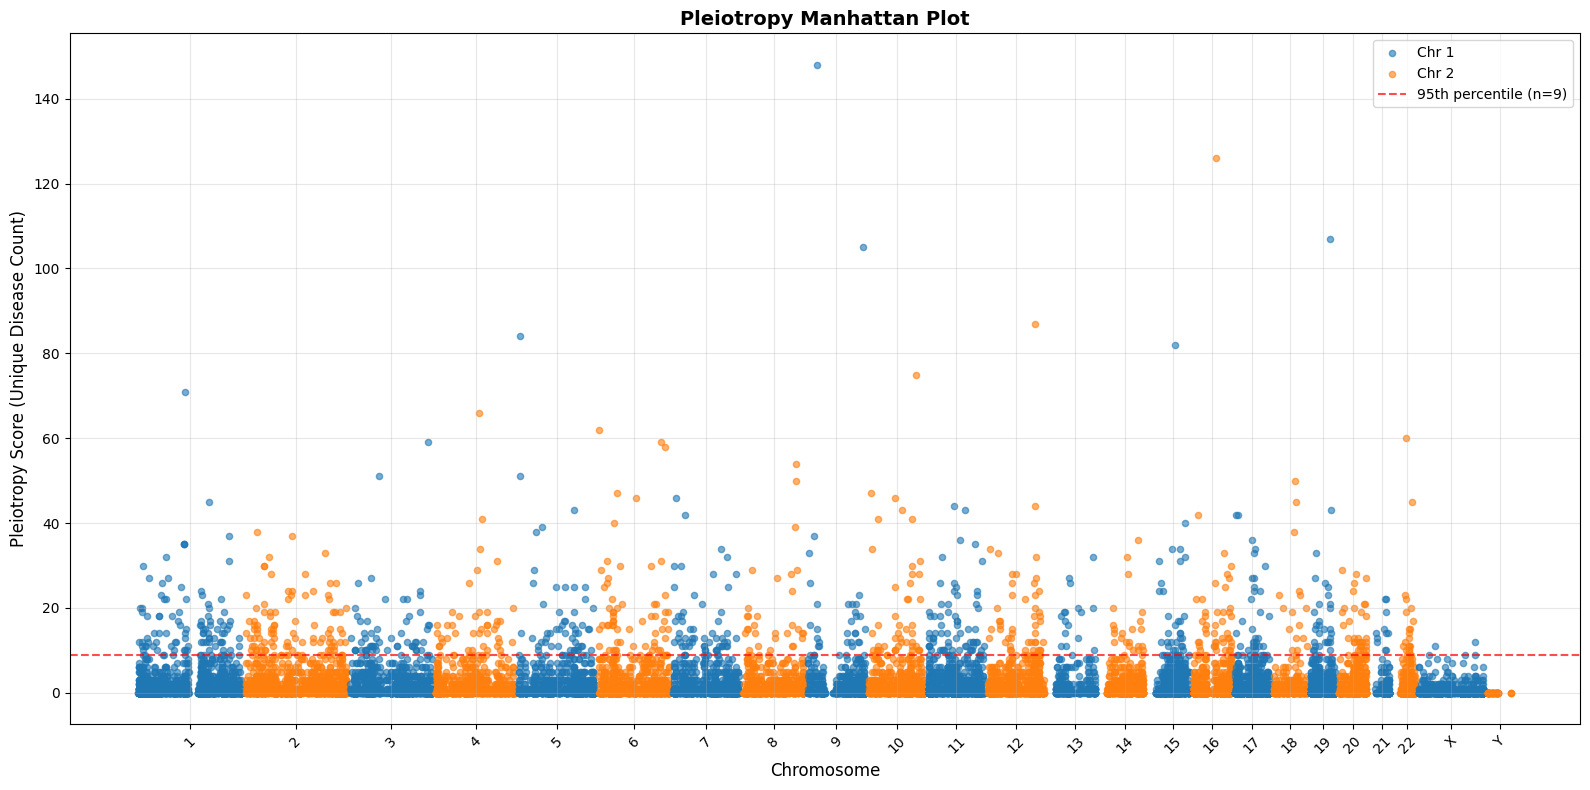

Total genes: 20083
Genes with pleiotropy > 0: 8285
Maximum pleiotropy score: 148
95th percentile threshold: 9.0


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure chromosome is properly ordered
joined_data['chromosome'] = joined_data['chromosome'].astype(str)
chromosome_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
joined_data['chromosome'] = pd.Categorical(joined_data['chromosome'], categories=chromosome_order, ordered=True)

# Sort by chromosome and position
joined_data = joined_data.sort_values(['chromosome', 'start'])

# Create cumulative positions for x-axis
joined_data['cumulative_pos'] = 0
cumulative_offset = 0

for chrom in chromosome_order:
    if chrom in joined_data['chromosome'].values:
        mask = joined_data['chromosome'] == chrom
        joined_data.loc[mask, 'cumulative_pos'] = joined_data.loc[mask, 'start'] + cumulative_offset
        cumulative_offset = joined_data.loc[mask, 'cumulative_pos'].max() + 1e7  # Add 10MB gap between chromosomes

# Create the plot
plt.figure(figsize=(16, 8))

# Color chromosomes alternately
colors = ['#1f77b4', '#ff7f0e']
for i, chrom in enumerate(chromosome_order):
    if chrom in joined_data['chromosome'].values:
        chrom_data = joined_data[joined_data['chromosome'] == chrom]
        plt.scatter(chrom_data['cumulative_pos'], chrom_data['unique_disease_count'], 
                   c=colors[i % 2], alpha=0.6, s=20, label=f'Chr {chrom}' if i < 2 else "")

# Customize the plot
plt.xlabel('Chromosome', fontsize=12)
plt.ylabel('Pleiotropy Score (Unique Disease Count)', fontsize=12)
plt.title('Pleiotropy Manhattan Plot', fontsize=14, fontweight='bold')

# Set x-axis ticks to chromosome centers
chromosome_centers = []
chromosome_labels = []
for chrom in chromosome_order:
    if chrom in joined_data['chromosome'].values:
        chrom_data = joined_data[joined_data['chromosome'] == chrom]
        center = (chrom_data['cumulative_pos'].min() + chrom_data['cumulative_pos'].max()) / 2
        chromosome_centers.append(center)
        chromosome_labels.append(chrom)

plt.xticks(chromosome_centers, chromosome_labels, rotation=45)
plt.grid(True, alpha=0.3)

# Add horizontal line for high pleiotropy threshold (e.g., top 5%)
threshold = np.percentile(joined_data['unique_disease_count'], 95)
plt.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, 
           label=f'95th percentile (n={threshold:.0f})')

plt.legend()
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Total genes: {len(joined_data)}")
print(f"Genes with pleiotropy > 0: {(joined_data['unique_disease_count'] > 0).sum()}")
print(f"Maximum pleiotropy score: {joined_data['unique_disease_count'].max()}")
print(f"95th percentile threshold: {threshold:.1f}")

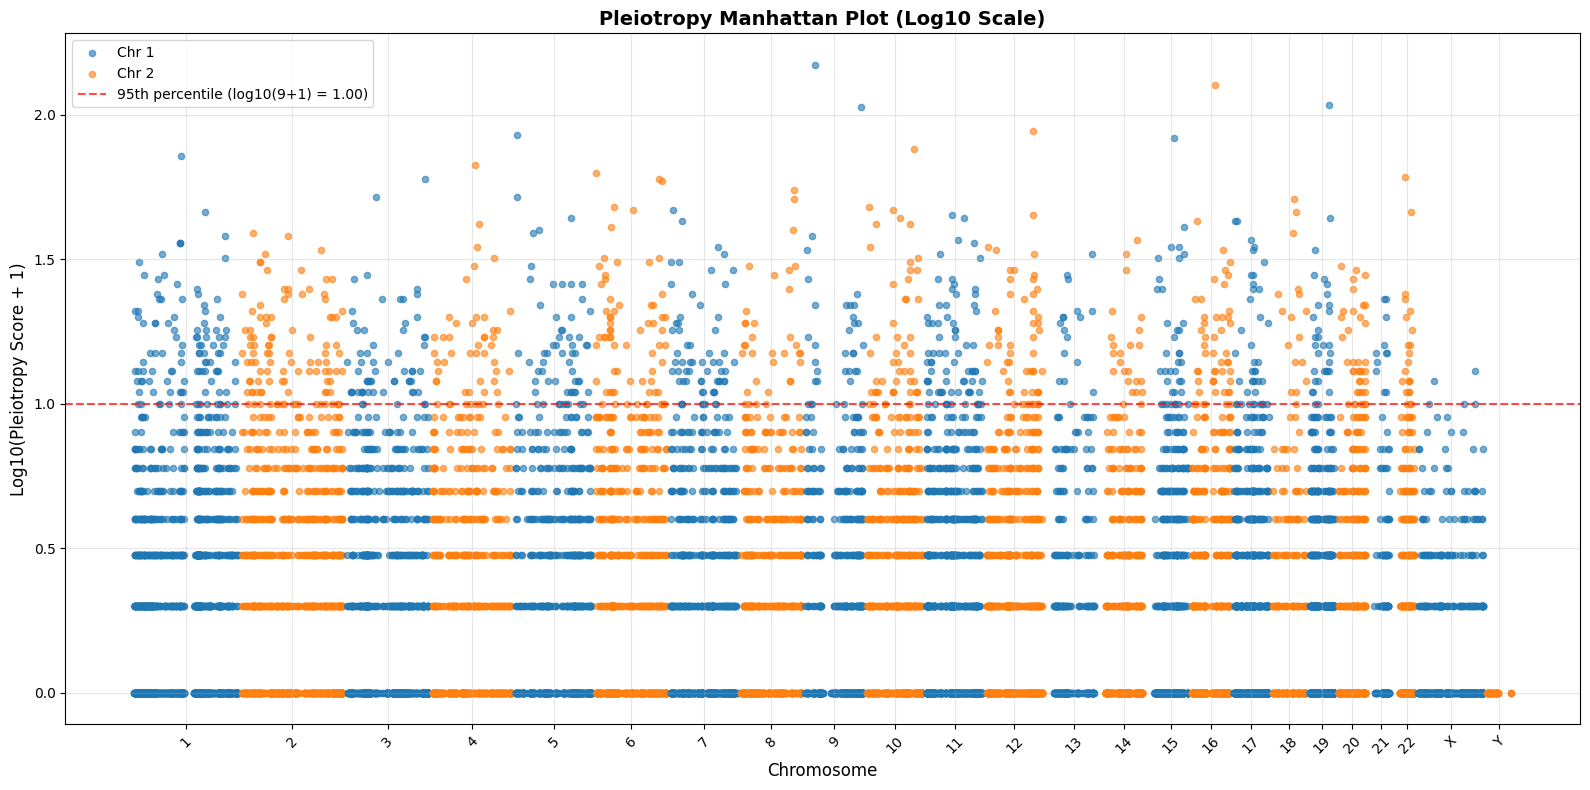

Total genes: 20083
Genes with pleiotropy > 0: 8285
Maximum pleiotropy score: 148
Maximum log10(pleiotropy+1): 2.17
95th percentile threshold (raw): 9.0
95th percentile threshold (log10): 1.00


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure chromosome is properly ordered
joined_data['chromosome'] = joined_data['chromosome'].astype(str)
chromosome_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
joined_data['chromosome'] = pd.Categorical(joined_data['chromosome'], categories=chromosome_order, ordered=True)

# Sort by chromosome and position
joined_data = joined_data.sort_values(['chromosome', 'start'])

# Create log10 transformed pleiotropy score
joined_data['log10_pleiotropy'] = np.log10(joined_data['unique_disease_count'] + 1)

# Create cumulative positions for x-axis
joined_data['cumulative_pos'] = 0
cumulative_offset = 0

for chrom in chromosome_order:
    if chrom in joined_data['chromosome'].values:
        mask = joined_data['chromosome'] == chrom
        joined_data.loc[mask, 'cumulative_pos'] = joined_data.loc[mask, 'start'] + cumulative_offset
        cumulative_offset = joined_data.loc[mask, 'cumulative_pos'].max() + 1e7  # Add 10MB gap between chromosomes

# Create the plot
plt.figure(figsize=(16, 8))

# Color chromosomes alternately
colors = ['#1f77b4', '#ff7f0e']
for i, chrom in enumerate(chromosome_order):
    if chrom in joined_data['chromosome'].values:
        chrom_data = joined_data[joined_data['chromosome'] == chrom]
        plt.scatter(chrom_data['cumulative_pos'], chrom_data['log10_pleiotropy'], 
                   c=colors[i % 2], alpha=0.6, s=20, label=f'Chr {chrom}' if i < 2 else "")

# Customize the plot
plt.xlabel('Chromosome', fontsize=12)
plt.ylabel('Log10(Pleiotropy Score + 1)', fontsize=12)
plt.title('Pleiotropy Manhattan Plot (Log10 Scale)', fontsize=14, fontweight='bold')

# Set x-axis ticks to chromosome centers
chromosome_centers = []
chromosome_labels = []
for chrom in chromosome_order:
    if chrom in joined_data['chromosome'].values:
        chrom_data = joined_data[joined_data['chromosome'] == chrom]
        center = (chrom_data['cumulative_pos'].min() + chrom_data['cumulative_pos'].max()) / 2
        chromosome_centers.append(center)
        chromosome_labels.append(chrom)

plt.xticks(chromosome_centers, chromosome_labels, rotation=45)
plt.grid(True, alpha=0.3)

# Add horizontal line for high pleiotropy threshold (e.g., top 5%)
threshold_raw = np.percentile(joined_data['unique_disease_count'], 95)
threshold_log = np.log10(threshold_raw + 1)
plt.axhline(y=threshold_log, color='red', linestyle='--', alpha=0.7, 
           label=f'95th percentile (log10({threshold_raw:.0f}+1) = {threshold_log:.2f})')

plt.legend()
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Total genes: {len(joined_data)}")
print(f"Genes with pleiotropy > 0: {(joined_data['unique_disease_count'] > 0).sum()}")
print(f"Maximum pleiotropy score: {joined_data['unique_disease_count'].max()}")
print(f"Maximum log10(pleiotropy+1): {joined_data['log10_pleiotropy'].max():.2f}")
print(f"95th percentile threshold (raw): {threshold_raw:.1f}")
print(f"95th percentile threshold (log10): {threshold_log:.2f}")

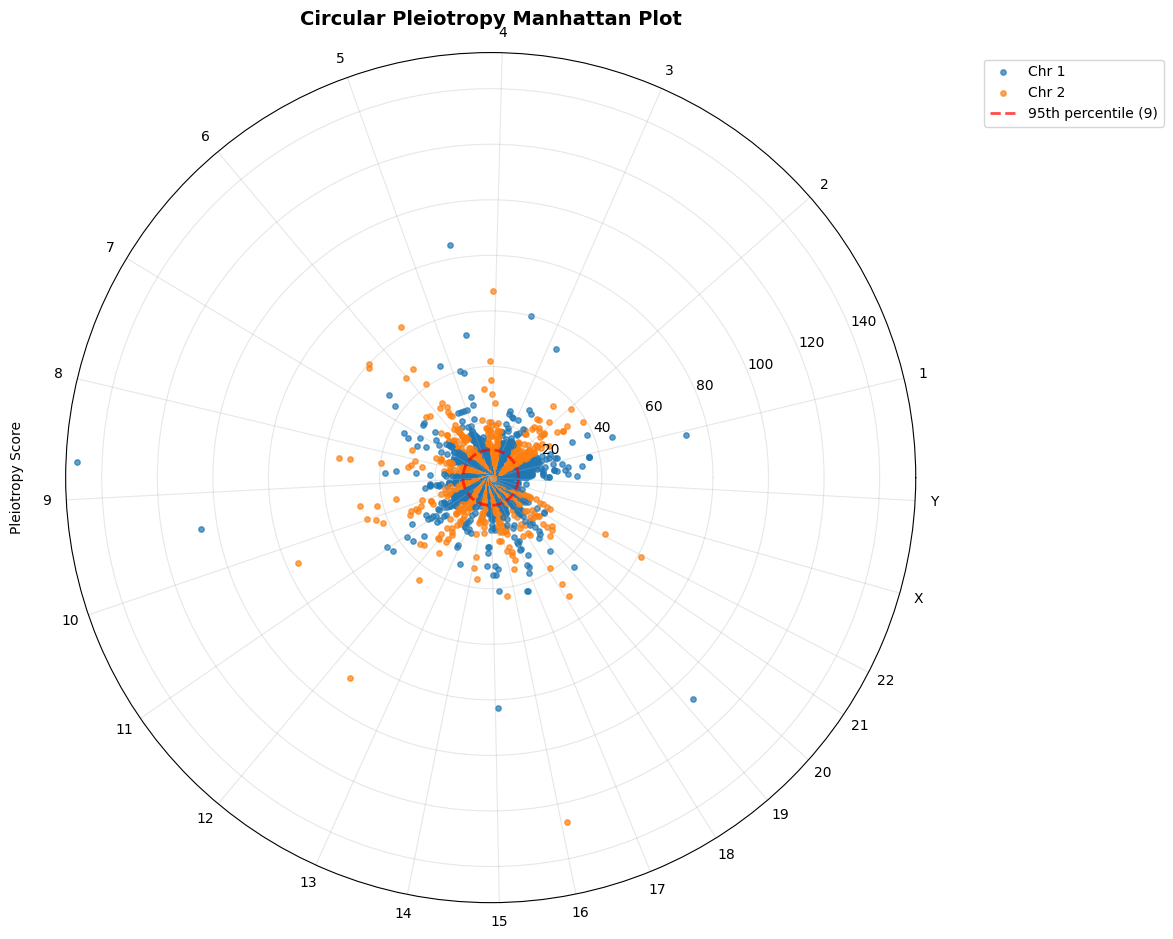

Total genes: 20083
Genes with pleiotropy > 0: 8285
Maximum pleiotropy score: 148
95th percentile threshold: 9.0


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure chromosome is properly ordered
joined_data['chromosome'] = joined_data['chromosome'].astype(str)
chromosome_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
joined_data['chromosome'] = pd.Categorical(joined_data['chromosome'], categories=chromosome_order, ordered=True)

# Sort by chromosome and position
joined_data = joined_data.sort_values(['chromosome', 'start'])

# Create cumulative positions for circular positioning
joined_data['cumulative_pos'] = 0
cumulative_offset = 0
chromosome_lengths = {}

for chrom in chromosome_order:
    if chrom in joined_data['chromosome'].values:
        mask = joined_data['chromosome'] == chrom
        joined_data.loc[mask, 'cumulative_pos'] = joined_data.loc[mask, 'start'] + cumulative_offset
        chrom_length = joined_data.loc[mask, 'start'].max() - joined_data.loc[mask, 'start'].min()
        chromosome_lengths[chrom] = chrom_length
        cumulative_offset = joined_data.loc[mask, 'cumulative_pos'].max() + 1e7

# Convert to polar coordinates
total_length = joined_data['cumulative_pos'].max()
joined_data['theta'] = 2 * np.pi * joined_data['cumulative_pos'] / total_length

# Create the circular plot
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

# Color chromosomes alternately
colors = ['#1f77b4', '#ff7f0e']
for i, chrom in enumerate(chromosome_order):
    if chrom in joined_data['chromosome'].values:
        chrom_data = joined_data[joined_data['chromosome'] == chrom]
        # Use pleiotropy score as radius (add offset to avoid center clustering)
        radius = chrom_data['unique_disease_count'] + 1  # Add 1 to avoid zeros at center
        ax.scatter(chrom_data['theta'], radius, 
                   c=colors[i % 2], alpha=0.7, s=15, label=f'Chr {chrom}' if i < 2 else "")

# Add chromosome labels
chromosome_positions = []
chromosome_labels = []
for chrom in chromosome_order:
    if chrom in joined_data['chromosome'].values:
        chrom_data = joined_data[joined_data['chromosome'] == chrom]
        center_theta = (chrom_data['theta'].min() + chrom_data['theta'].max()) / 2
        chromosome_positions.append(center_theta)
        chromosome_labels.append(chrom)

# Set chromosome labels
ax.set_thetagrids(np.degrees(chromosome_positions), chromosome_labels)

# Customize the plot
ax.set_ylim(0, joined_data['unique_disease_count'].max() + 5)
ax.set_ylabel('Pleiotropy Score', labelpad=30)
ax.set_title('Circular Pleiotropy Manhattan Plot', pad=20, fontsize=14, fontweight='bold')

# Add threshold circle
threshold = np.percentile(joined_data['unique_disease_count'], 95)
theta_circle = np.linspace(0, 2*np.pi, 100)
radius_circle = np.full_like(theta_circle, threshold + 1)  # Add 1 for offset
ax.plot(theta_circle, radius_circle, 'r--', alpha=0.7, linewidth=2, 
        label=f'95th percentile ({threshold:.0f})')

# Add grid
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Total genes: {len(joined_data)}")
print(f"Genes with pleiotropy > 0: {(joined_data['unique_disease_count'] > 0).sum()}")
print(f"Maximum pleiotropy score: {joined_data['unique_disease_count'].max()}")
print(f"95th percentile threshold: {threshold:.1f}")